## 1. Import Necessary Library

In [45]:
import pandas as pd
import tensorflow as tr
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D,MaxPool2D,UpSampling2D
from tensorflow.keras.datasets import mnist
import numpy as np
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## 2. Data Collection

In [30]:
(X_train, _), (X_test, _) = mnist.load_data()

In [31]:
X_train.shape,X_test.shape

((60000, 28, 28), (10000, 28, 28))

In [32]:
X_train = X_train.reshape(60000, 28, 28,1)
X_test = X_test.reshape(10000, 28, 28,1)

In [33]:
X_train.shape,X_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

## 3. Data Preparation

### 3.1  Data Normalise

In [34]:
X_train.min(),X_train.max()

(np.uint8(0), np.uint8(255))

In [35]:
X_train = X_train/255.0
X_test = X_test/255.0

In [36]:
X_train.min(),X_train.max()

(np.float64(0.0), np.float64(1.0))

### 3.2 Add Noise

In [14]:
#"0.2*np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)

In [37]:
X_train_Noise = X_train+ 0.2*np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
X_test_Noise = X_test+0.2*np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)

### 3.3 Clip the Data

In [38]:
X_train_Clip = np.clip( a = X_train_Noise,a_min=0,a_max=1)
X_test_Clip = np.clip( a = X_test_Noise,a_min=0,a_max=1)

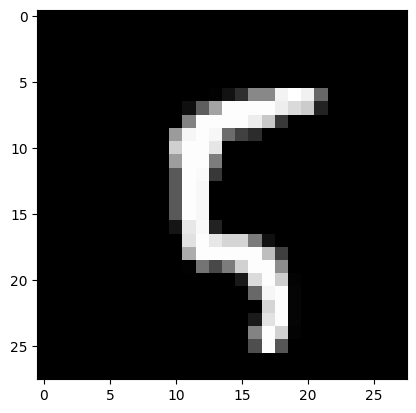

In [40]:
plt.imshow(X_train[100],cmap="grey")

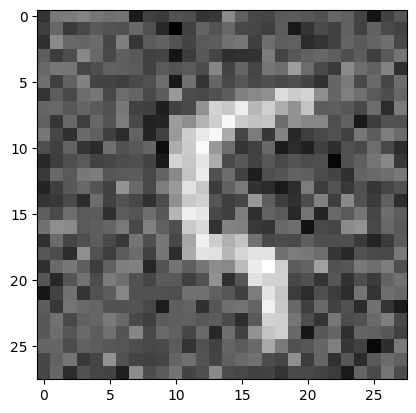

In [39]:
plt.imshow(X_train_Noise[100],cmap="grey")

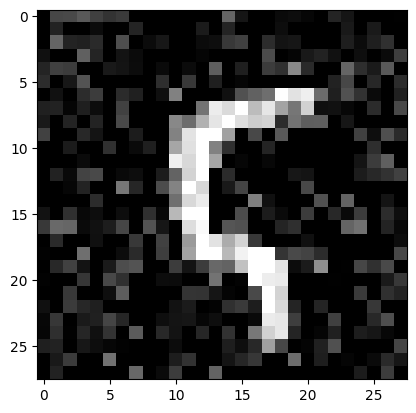

In [41]:
plt.imshow(X_train_Clip[100],cmap="grey")

## 4. Module Building

In [57]:
model = Sequential()
## Encoder Layer


model.add(Conv2D(filters = 16,kernel_size = (3,3),strides=(1, 1),padding='same',activation = 'relu',input_shape = (28,28,1)))
model.add(MaxPool2D(2,2))
model.add(Conv2D(filters = 8,kernel_size = (3,3),strides=(1, 1),padding='same',activation = 'relu'))
model.add(MaxPool2D(2,2))


## Decoder
model.add(Conv2D(filters = 8,kernel_size = (3,3),strides=(1, 1),padding='same',activation = 'relu'))
model.add(UpSampling2D(size=(2, 2)))
model.add(Conv2D(filters = 16,kernel_size = (3,3),strides=(1, 1),padding='same',activation = 'relu'))
model.add(UpSampling2D(size=(2, 2)))
model.add(Conv2D(filters = 1,kernel_size = (3,3),strides=(1, 1),padding='same',activation = 'relu'))

model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_44 (Conv2D)                   │ (None, 28, 28, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_25 (MaxPooling2D)      │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_45 (Conv2D)                   │ (None, 14, 14, 8)           │           1,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_26 (MaxPooling2D)      │ (None, 7, 7, 8)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_46 (Conv2D)                   │ (None, 7, 7, 8)             │             584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_13 (UpSampling2D)      │ (None, 14, 14, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_47 (Conv2D)                   │ (None, 14, 14, 16)          │           1,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_14 (UpSampling2D)      │ (None, 28, 28, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_48 (Conv2D)                   │ (None, 28, 28, 1)           │             145 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,217 (12.57 KB)

 Trainable params: 3,217 (12.57 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Module Complile

In [58]:
model.compile(optimizer='adam',loss="mean_squared_error",metrics=["accuracy"])

## 6. Module Training

In [59]:
model.fit(x=X_train_Clip,y=X_train,batch_size=32,epochs=5,validation_data=(X_test_Clip,X_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.8134 - loss: 0.0124 - val_accuracy: 0.8136 - val_loss: 0.0077
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8147 - loss: 0.0071 - val_accuracy: 0.8139 - val_loss: 0.0065
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8149 - loss: 0.0062 - val_accuracy: 0.8139 - val_loss: 0.0059
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8149 - loss: 0.0059 - val_accuracy: 0.8140 - val_loss: 0.0056
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.8150 - loss: 0.0057 - val_accuracy: 0.8141 - val_loss: 0.0054


## 7. Module Evaluate

In [60]:
model.evaluate(X_test_Clip,X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8141 - loss: 0.0054


[0.005432493519037962, 0.8140519261360168]

## 8. Module Prediction

In [61]:
X_Predict = model.predict(X_test_Clip)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


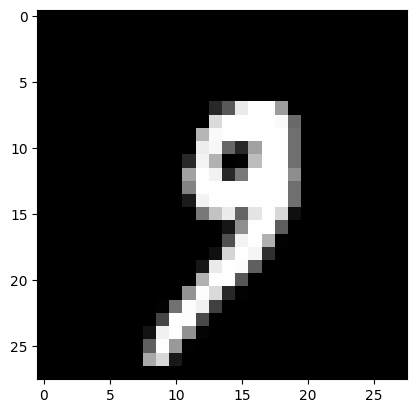

In [67]:
plt.imshow(X_test[1000],cmap="grey")

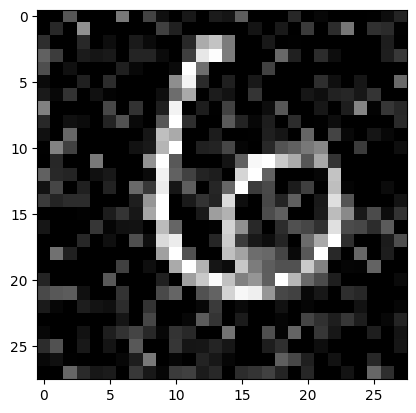

In [64]:
plt.imshow(X_test_Clip[100],cmap="grey")

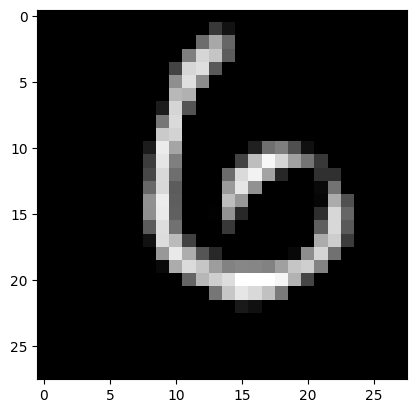

In [65]:
plt.imshow(X_Predict[100],cmap="grey")

In [66]:
model.save("denoise_image.h5")